C:\Users\DELL\AppData\Local\Temp\ipykernel_25960\4182925124.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CASE', y='avg_bleu', data=dpo_df, palette='viridis')


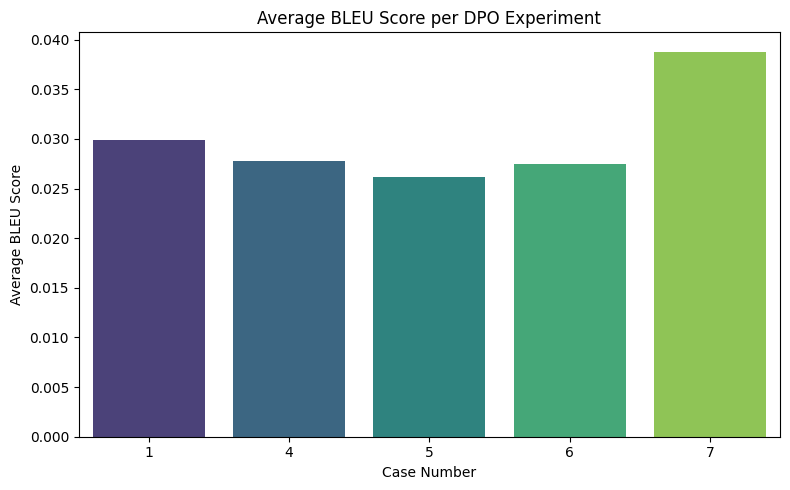

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV from the 'deliverables' folder
file_path = 'deliverables/dpo_top5_experiments.csv'
dpo_df = pd.read_csv(file_path)

# Identify BLEU score columns (adjust if your column names are different)
bleu_columns = [col for col in dpo_df.columns if 'BLEU' in col.upper()]

# Calculate average BLEU for each case
dpo_df['avg_bleu'] = dpo_df[bleu_columns].mean(axis=1)

# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x='CASE', y='avg_bleu', data=dpo_df, palette='viridis')
plt.title("Average BLEU Score per DPO Experiment")
plt.xlabel("Case Number")
plt.ylabel("Average BLEU Score")
plt.tight_layout()
plt.show()


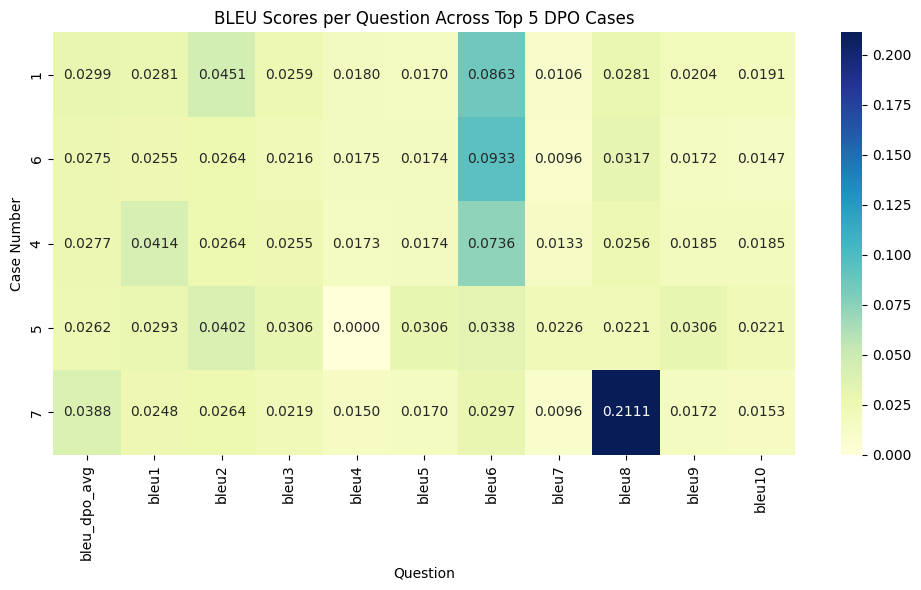

In [10]:
# Prepare BLEU score matrix
bleu_matrix = dpo_df.set_index('CASE')[bleu_columns]

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(bleu_matrix, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title("BLEU Scores per Question Across Top 5 DPO Cases")
plt.xlabel("Question")
plt.ylabel("Case Number")
plt.tight_layout()
plt.show()


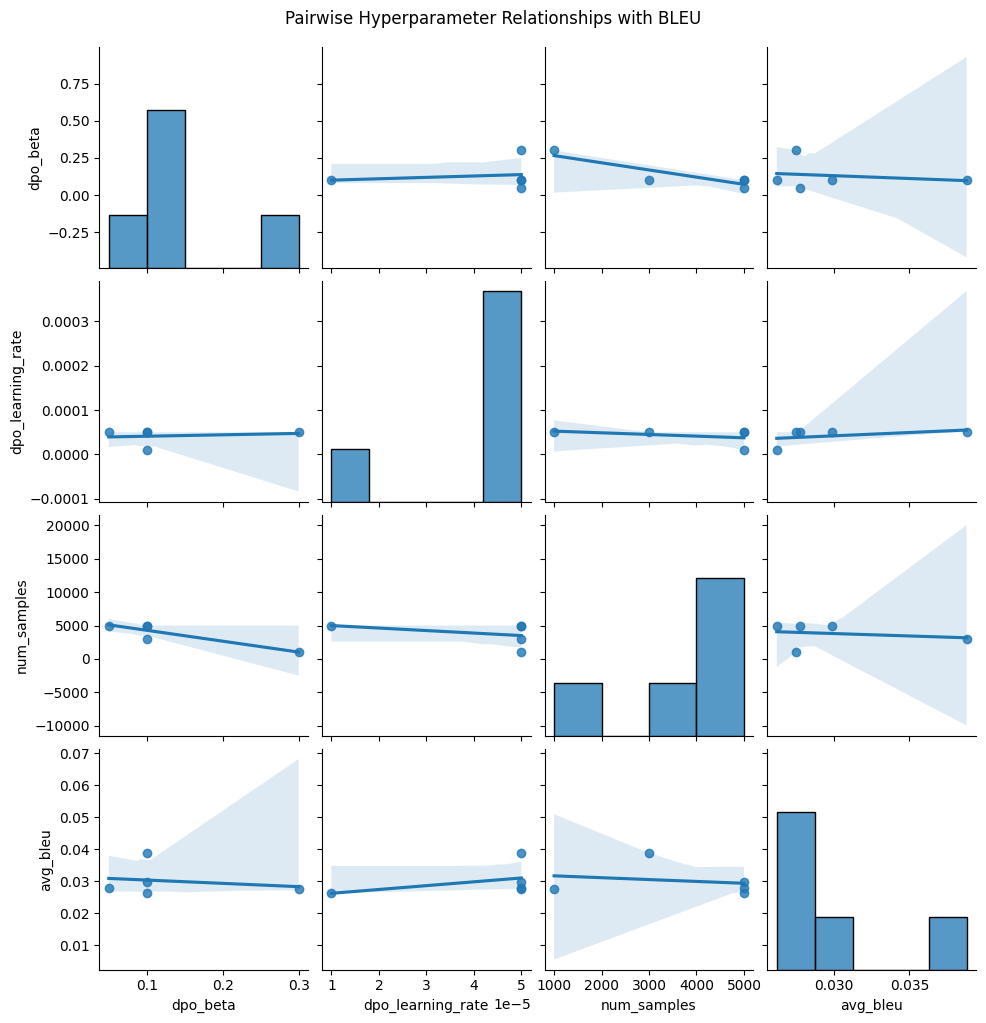

In [11]:
# Pairplot of beta, learning rate, samples vs avg BLEU
sns.pairplot(dpo_df, vars=['dpo_beta', 'dpo_learning_rate', 'num_samples', 'avg_bleu'], kind='reg')
plt.suptitle("Pairwise Hyperparameter Relationships with BLEU", y=1.02)
plt.show()

In [13]:
dpo_df.columns

Index(['CASE', 'CHANGE', 'timestamp', 'training_time', 'base_model',
       'lora_model_path', 'dataset', 'num_samples', 'dpo_beta',
       'dpo_learning_rate', 'dpo_batch_size', 'dpo_epochs', 'dpo_grad_accum',
       'max_length', 'bleu_dpo_avg', 'q1_output', 'bleu1', 'q2_output',
       'bleu2', 'q3_output', 'bleu3', 'q4_output', 'bleu4', 'q5_output',
       'bleu5', 'q6_output', 'bleu6', 'q7_output', 'bleu7', 'q8_output',
       'bleu8', 'q9_output', 'bleu9', 'q10_output', 'bleu10', 'avg_bleu'],
      dtype='object')

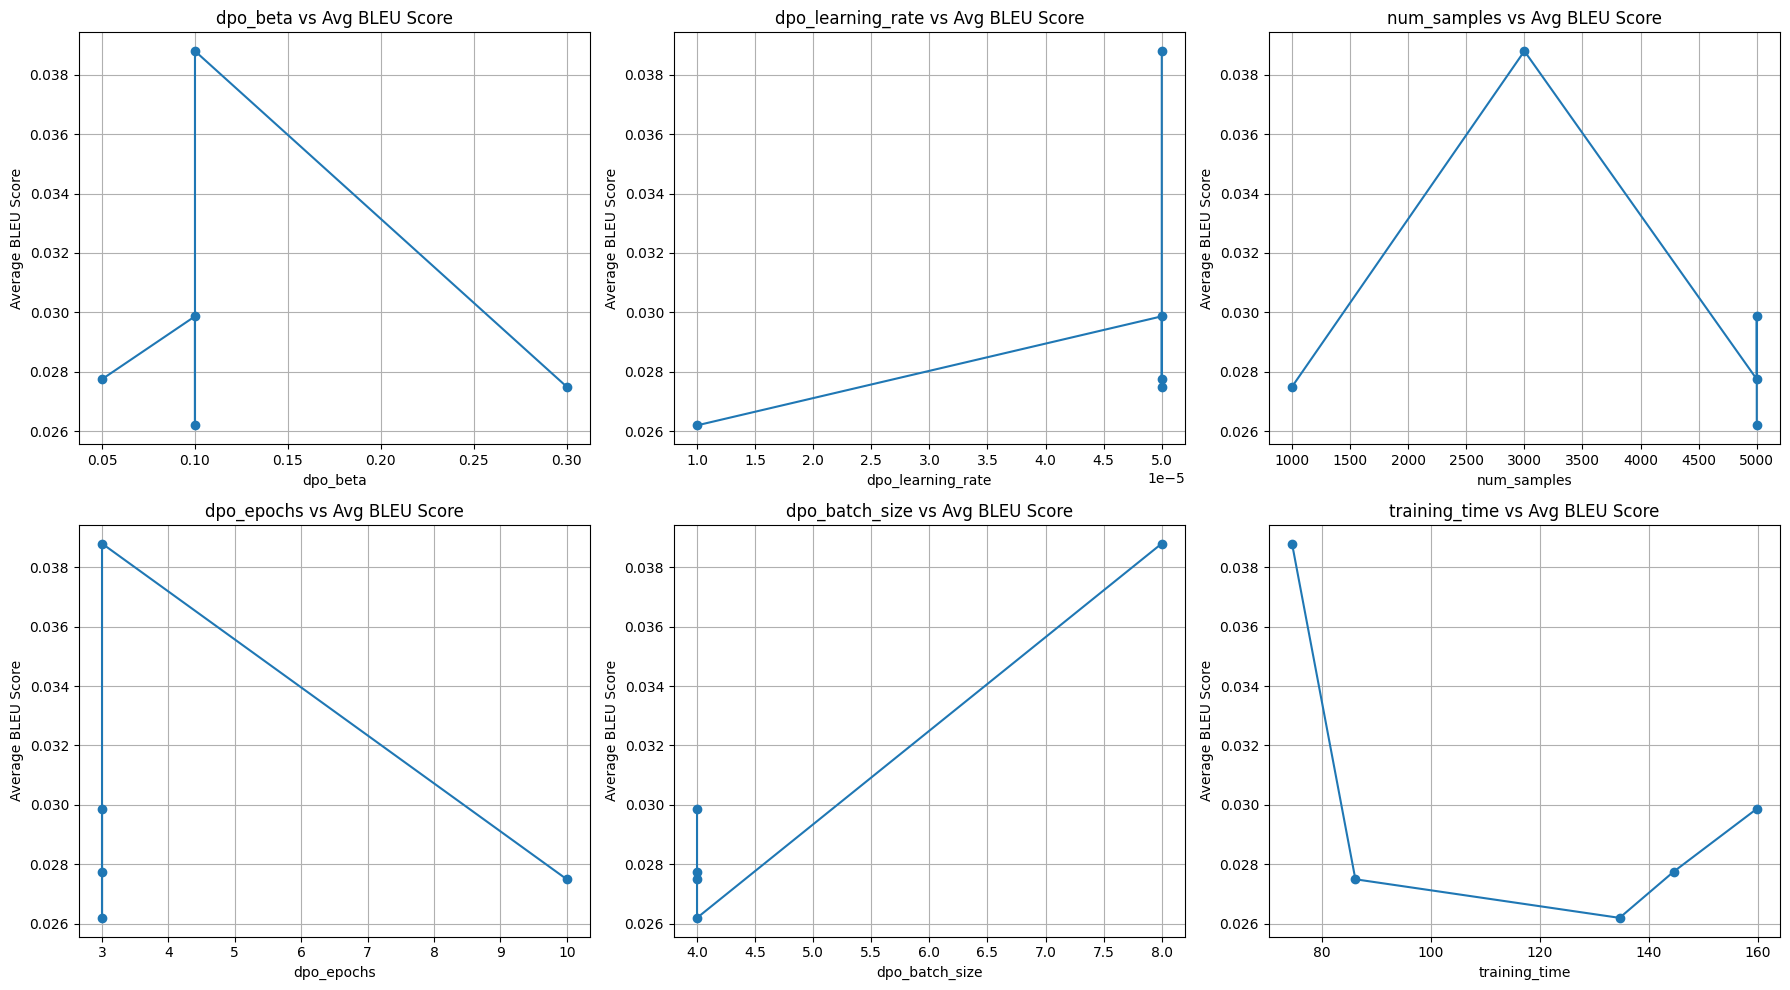

In [15]:
# Calculate average BLEU if not already done
if 'avg_bleu' not in dpo_df.columns:
    dpo_df['avg_bleu'] = dpo_df[bleu_columns].mean(axis=1)

# List of parameters to visualize
param_cols = ['dpo_beta', 'dpo_learning_rate', 'num_samples', 'dpo_epochs', 'dpo_batch_size', 'training_time']

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, param in enumerate(param_cols):
    # Sort data by the parameter
    sorted_df = dpo_df.sort_values(by=param)
    
    # Plot
    axes[i].plot(sorted_df[param], sorted_df['avg_bleu'], marker='o', linestyle='-')
    axes[i].set_title(f"{param} vs Avg BLEU Score")
    axes[i].set_xlabel(param)
    axes[i].set_ylabel("Average BLEU Score")
    axes[i].grid(True)

# Hide any unused subplot (in case of odd number)
for j in range(len(param_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
